In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#analyse des données M1 GID IA ENI

#Chargement du fichier en csv

df = pd.read_csv('m1.csv')
df

,Groupe Number,Name,Matricule,Etablissement d'origine
0,1.0,RAHERINIRINA Jocelyn,4562,CNTEMAD
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,2.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
64,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN
66,NaN,SOLOFONOTOAVINDRAINY Hery Nasandratra,2995,ENI
67,24.0,RANDRIANJAFISOA Kiady Luciano,2999,ENI


In [3]:
df.head()

,Groupe Number,Name,Matricule,Etablissement d'origine
0,1.0,RAHERINIRINA Jocelyn,4562,CNTEMAD
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,2.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


In [4]:
#affichage de 10 premiers

df.head(10)

,Groupe Number,Name,Matricule,Etablissement d'origine
0,1.0,RAHERINIRINA Jocelyn,4562,CNTEMAD
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,2.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,3.0,RAMANANTSOA Antsa Berthieu,4572,ENS
7,NaN,RAKOTOZAFY Nantenaina Jérémiah,2858,ENI
8,NaN,RAZANATSOA Aimé Freddy,4559,INFOCENTRE
9,4.0,RANDRIAMAHOLISON Tolotra Ny Aina Kevin,4548,Politech-Diego


In [5]:
#Nettoyage des données &eneleve les valeur NaN par des vides
df = df.fillna('')


In [6]:
df

,Groupe Number,Name,Matricule,Etablissement d'origine
0,1,RAHERINIRINA Jocelyn,4562,CNTEMAD
1,,,,
2,,,,
3,2,,,
4,,,,
...,...,...,...,...
64,,,,
65,,,,
66,,SOLOFONOTOAVINDRAINY Hery Nasandratra,2995,ENI
67,24,RANDRIANJAFISOA Kiady Luciano,2999,ENI


In [7]:
# Supprimer les lignes complètement vides
df = df[~((df['Name'] == '') & (df['Matricule'] == '') & (df['Etablissement d\'origine'] == ''))]

In [8]:
df

,Groupe Number,Name,Matricule,Etablissement d'origine
0,1,RAHERINIRINA Jocelyn,4562,CNTEMAD
6,3,RAMANANTSOA Antsa Berthieu,4572,ENS
7,,RAKOTOZAFY Nantenaina Jérémiah,2858,ENI
8,,RAZANATSOA Aimé Freddy,4559,INFOCENTRE
9,4,RANDRIAMAHOLISON Tolotra Ny Aina Kevin,4548,Politech-Diego
10,,ANDRIANANTENAINA Fréderic,2820,ENI
11,,ANDRIARIMINO Miarilanto Ioty,4551,U-Magis
12,5,ANDRIANOMENJANAHARY Jean Marceau,4558,faculté des sciences
13,,HARENTSOA Anjavola Nantenaina,2854,ENI
14,,ANJARAMANDRESY Miandry Finiavana,4549,CNTEMAD


In [9]:
df.shape

(55, 4)

In [10]:
#nombres des lignes après nettoyage
len(df)

55

In [12]:
#nombres des colonnes après nettoyage
len(df.columns)

4

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 55 entries, 0 to 68
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Groupe Number            55 non-null     object
 1   Name                     55 non-null     object
 2   Matricule                55 non-null     object
 3   Etablissement d'origine  55 non-null     object
dtypes: object(4)
memory usage: 2.1+ KB


In [14]:
df.describe()

,Groupe Number,Name,Matricule,Etablissement d'origine
count,55,55,55,55
unique,20,55,54,18
top,,NALAHANDRAZA Dinah,2826,ENI
freq,36,1,2,17


In [15]:
# Garder uniquement les lignes avec des étudiants (nom non vide)
df_students = df[df['Name'] != ''].copy()

In [16]:
df_students

,Groupe Number,Name,Matricule,Etablissement d'origine
0,1,RAHERINIRINA Jocelyn,4562,CNTEMAD
6,3,RAMANANTSOA Antsa Berthieu,4572,ENS
7,,RAKOTOZAFY Nantenaina Jérémiah,2858,ENI
8,,RAZANATSOA Aimé Freddy,4559,INFOCENTRE
9,4,RANDRIAMAHOLISON Tolotra Ny Aina Kevin,4548,Politech-Diego
10,,ANDRIANANTENAINA Fréderic,2820,ENI
11,,ANDRIARIMINO Miarilanto Ioty,4551,U-Magis
12,5,ANDRIANOMENJANAHARY Jean Marceau,4558,faculté des sciences
13,,HARENTSOA Anjavola Nantenaina,2854,ENI
14,,ANJARAMANDRESY Miandry Finiavana,4549,CNTEMAD


In [17]:
# 1. GROUPEMENT PAR ÉTABLISSEMENT
etablissement_counts = df_students['Etablissement d\'origine'].value_counts()
total_etudiants = len(df_students)

In [18]:
etablissement_counts

ENI                      16
ENS                      13
Faculté des sciences      6
faculté des sciences      3
CNTEMAD                   2
EMIT                      2
Faculté des Sciences      1
Faculté des sciences      1
OniFRa                    1
U-Magis                   1
Politech-Diego            1
faculté                   1
CNTEMAD                   1
IFT                       1
INFOCENTRE                1
ENEAM                     1
HEI                       1
E-Media                   1
Name: Etablissement d'origine, dtype: int64

In [19]:
total_etudiants

54

In [20]:
# Calcul des pourcentages
etablissement_percentages = (etablissement_counts / total_etudiants) * 100
etablissement_percentages

ENI                      29.629630
ENS                      24.074074
Faculté des sciences     11.111111
faculté des sciences      5.555556
CNTEMAD                   3.703704
EMIT                      3.703704
Faculté des Sciences      1.851852
Faculté des sciences      1.851852
OniFRa                    1.851852
U-Magis                   1.851852
Politech-Diego            1.851852
faculté                   1.851852
CNTEMAD                   1.851852
IFT                       1.851852
INFOCENTRE                1.851852
ENEAM                     1.851852
HEI                       1.851852
E-Media                   1.851852
Name: Etablissement d'origine, dtype: float64

In [23]:
print("=== RÉPARTITION DES ÉTUDIANTS PAR ÉTABLISSEMENT ===")
print(f"Nombre total d'étudiants: {total_etudiants}\n")

for etab, count in etablissement_counts.items():
    pct = (count / total_etudiants) * 100
    print(f"{etab}: {count} étudiant(s) ({pct:.1f}%)")
    


=== RÉPARTITION DES ÉTUDIANTS PAR ÉTABLISSEMENT ===
Nombre total d'étudiants: 54

ENI: 16 étudiant(s) (29.6%)
ENS: 13 étudiant(s) (24.1%)
Faculté des sciences : 6 étudiant(s) (11.1%)
faculté des sciences : 3 étudiant(s) (5.6%)
CNTEMAD: 2 étudiant(s) (3.7%)
EMIT: 2 étudiant(s) (3.7%)
Faculté des Sciences : 1 étudiant(s) (1.9%)
Faculté des sciences: 1 étudiant(s) (1.9%)
OniFRa: 1 étudiant(s) (1.9%)
U-Magis: 1 étudiant(s) (1.9%)
Politech-Diego : 1 étudiant(s) (1.9%)
faculté : 1 étudiant(s) (1.9%)
CNTEMAD : 1 étudiant(s) (1.9%)
IFT: 1 étudiant(s) (1.9%)
INFOCENTRE: 1 étudiant(s) (1.9%)
ENEAM: 1 étudiant(s) (1.9%)
HEI: 1 étudiant(s) (1.9%)
E-Media: 1 étudiant(s) (1.9%)


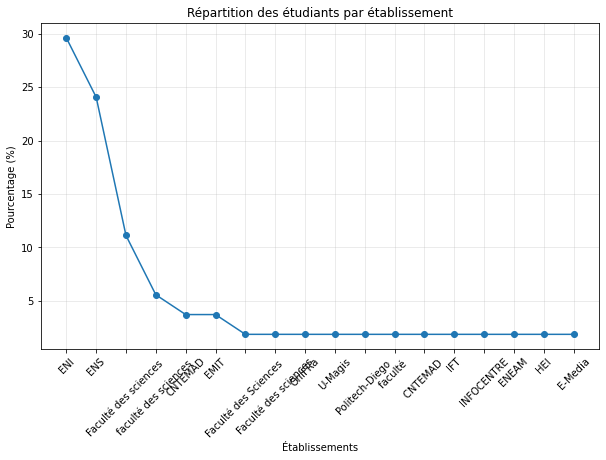

In [28]:
etablissements = list(etablissement_counts.index)
pourcentages = []

for count in etablissement_counts.values:
    pct = (count / total_etudiants) * 100
    pourcentages.append(pct)



plt.figure(figsize=(10, 6))
plt.plot(etablissements, pourcentages, 'o-')

plt.xlabel('Établissements')
plt.ylabel('Pourcentage (%)')
plt.title('Répartition des étudiants par établissement')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

 CLASSEMENT ANCIENS vs NOVICES 
Novices (Autres): 38 étudiant(s) (70.4%)
Anciens élèves (ENI): 16 étudiant(s) (29.6%)


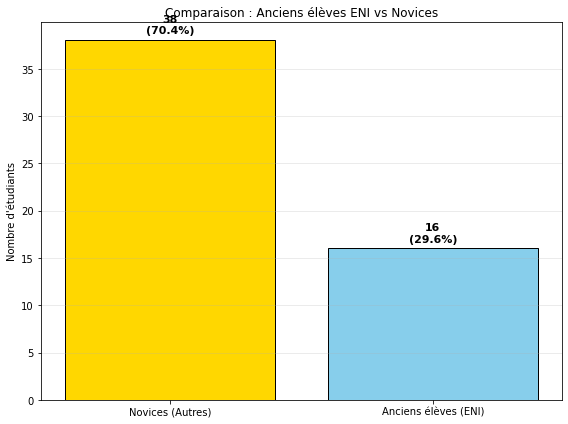

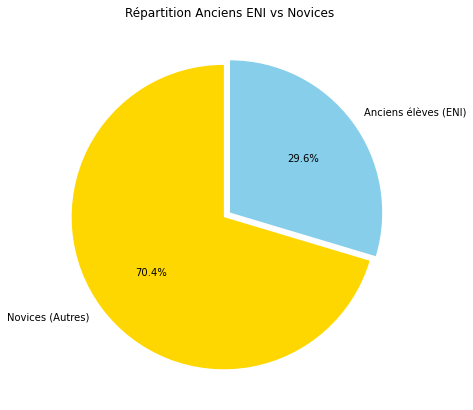

In [30]:

# Créer une nouvelle colonne avec la catégorie
def classer_etablissement(etab):
    if etab == 'ENI':
        return 'Anciens élèves (ENI)'
    else:
        return 'Novices (Autres)'


df = df[df['Name'] != ''].copy()
df['Statut'] = df['Etablissement d\'origine'].apply(classer_etablissement)  

#  Compter par catégorie
statut_counts = df['Statut'].value_counts()
total = len(df)
pourcentages = (statut_counts / total) * 100

#  Afficher les résultats
print(" CLASSEMENT ANCIENS vs NOVICES ")
for statut, count in statut_counts.items():
    pct = (count / total) * 100
    print(f"{statut}: {count} étudiant(s) ({pct:.1f}%)")

# 5. Graphique en barres
plt.figure(figsize=(8, 6))
bars = plt.bar(statut_counts.index, statut_counts.values, color=['gold', 'skyblue'], edgecolor='black')

# Ajouter les valeurs sur les barres
for bar, count in zip(bars, statut_counts.values):
    pct = (count / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel("Nombre d'étudiants")
plt.title("Comparaison : Anciens élèves ENI vs Novices")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Graphique en camembert (optionnel)
plt.figure(figsize=(7, 7))
plt.pie(statut_counts.values, labels=statut_counts.index, autopct='%1.1f%%', 
        colors=['gold', 'skyblue'], startangle=90, explode=(0.05, 0))
plt.title("Répartition Anciens ENI vs Novices")
plt.show()

In [31]:
plt.savefig('graphique_anciens_vs_novices.png', dpi=300, bbox_inches='tight')
print(" Sauvegardé: graphique_anciens_vs_novices.png")

# Sauvegarde en PDF
plt.savefig('graphique_anciens_vs_novices.pdf', bbox_inches='tight')
print(" Sauvegardé: graphique_anciens_vs_novices.pdf")

 Sauvegardé: graphique_anciens_vs_novices.png
 Sauvegardé: graphique_anciens_vs_novices.pdf


<Figure size 432x288 with 0 Axes>